In [338]:
%matplotlib inline
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}
%load_ext autoreload
%autoreload 2

import pickle
import time as t
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import time as t
from scipy.signal import fftconvolve, oaconvolve
from scipy.ndimage import zoom
from scipy.ndimage import map_coordinates
import MulensModel as mm
import warnings

from IRSMicroLensing import IRSCaustics as IRSC
from IRSMicroLensing import IRSFunctions as IRSF

import numexpr

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['figure.titlesize'] = 20
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['figure.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['mathtext.fontset'] = 'cm'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Calculated offsets

In [339]:
args = {
    'sep2': '0.8',
    'angle2': '45',
    'planet_mass_ratio': '0.01',
    'origin': 'triple_offset'  # Options: 'triple_offset', 'binary_offset', 'cm'

}

''' Preparing lens parameters '''
# Big planet parameters
s1 = 0.8
alpha1 = 0
q1 = 1e-3

# Small planet parameters
s2 = np.float64(numexpr.evaluate(args['sep2']).item())
alpha2 = np.float64(args['angle2'])
q2 = np.float64(args['planet_mass_ratio']) * q1

print(f'q1 = {q1}')
print(f'q2 = {q2}')
print(f's1 = {s1}')
print(f's2 = {s2}')
print(f'alpha1 = {alpha1}')
print(f'alpha2 = {alpha2}')

# Defining single lens attributes
single_lens_attributes = np.array([
    [0, 0, 1]
])

# Defining binary lens attributes
binary_lens_attributes = np.array([
    [0, 0, 1],
    [s1*np.cos(np.deg2rad(alpha1)), s1*np.sin(np.deg2rad(alpha1)), q1],
])

# Triple lens attributes
triple_lens_attributes = np.array([
    [0, 0, 1],
    [s1*np.cos(np.deg2rad(alpha1)), s1*np.sin(np.deg2rad(alpha1)), q1],
    [s2*np.cos(np.deg2rad(alpha2)), s2*np.sin(np.deg2rad(alpha2)), q2]
])

# Rotation matrix for first planet
first_planet_DCM = np.array([
    [np.cos(np.deg2rad(alpha1)), -np.sin(np.deg2rad(alpha1))],
    [np.sin(np.deg2rad(alpha1)), np.cos(np.deg2rad(alpha1))]
])

# Rotation matrix for second planet
second_planet_DCM = np.array([
    [np.cos(np.deg2rad(alpha2)), -np.sin(np.deg2rad(alpha2))],
    [np.sin(np.deg2rad(alpha2)), np.cos(np.deg2rad(alpha2))]
])

# Calculating translation of coordinate origin for each planet
q1 = triple_lens_attributes[1, 2]
q2 = triple_lens_attributes[2, 2]

delta1_rot = np.array([q1 / ((1 + q1) * (s1 + 1/s1)), 0]).reshape(-1, 1)
delta2_rot = np.array([q2 / ((1 + q2) * (s2 + 1/s2)), 0]).reshape(-1, 1)

delta1 = np.dot(first_planet_DCM, delta1_rot).reshape(2)
delta2 = np.dot(second_planet_DCM, delta2_rot).reshape(2)

total_offset = (q1*delta1 + q2*delta2)/(q1 + q2)
print(f'Total offset: {total_offset}')
print(f'Binary offset: {delta1}')

CM_sum = 0

for i in range(2):
    CM_sum += binary_lens_attributes[i, :2] * binary_lens_attributes[i, 2]

total_M = np.sum(binary_lens_attributes[:, 2])

lens_CM = CM_sum / total_M

print(f'CM of the triple lens: {lens_CM}')

q1 = 0.001
q2 = 1e-05
s1 = 0.8
s2 = 0.8
alpha1 = 0
alpha2 = 45.0
Total offset: [4.82526785e-04 3.41511572e-08]
Binary offset: [0.00048732 0.        ]
CM of the triple lens: [0.0007992 0.       ]


#### Read in caustic files and change angular resolution

In [ ]:
# Single lens
single_lens = IRSC.caustic_reader('../Unity/Simulations/Collection_0.8/single_1e11.pkl')

# Binary lens
binary_lens = IRSC.caustic_reader('../Unity/Simulations/Collection_0.8/binary_1e11.pkl')

ang_width = single_lens.ang_width
pixels = single_lens.pixels
ang_res = ang_width / (pixels - 1)

# Calculating area of annulus
A_ann = np.pi * (single_lens.y_plus**2 - single_lens.y_minus**2)

# Calculating ray density within annulus
sigma_ann = single_lens.num_rays / A_ann

# Calculating area of pixel
A_pix = (ang_res * 1.0)**2
old_A_pix = (single_lens.ang_res * 1.0)**2

print(f'Old area of pixel: {old_A_pix:.5e}')
print(f'New area of pixel: {A_pix:.5e}')

print(f'Old angular resolution: {single_lens.ang_res:.5e}')
print(f'New angular resolution: {ang_res:.5e}')

Old area of pixel: 1.47468e-09
New area of pixel: 1.47616e-09
Old angular resolution: 3.84016e-05
New angular resolution: 3.84208e-05


#### Increasing angular resolution using scale factor and defining source profile

(208, 208)


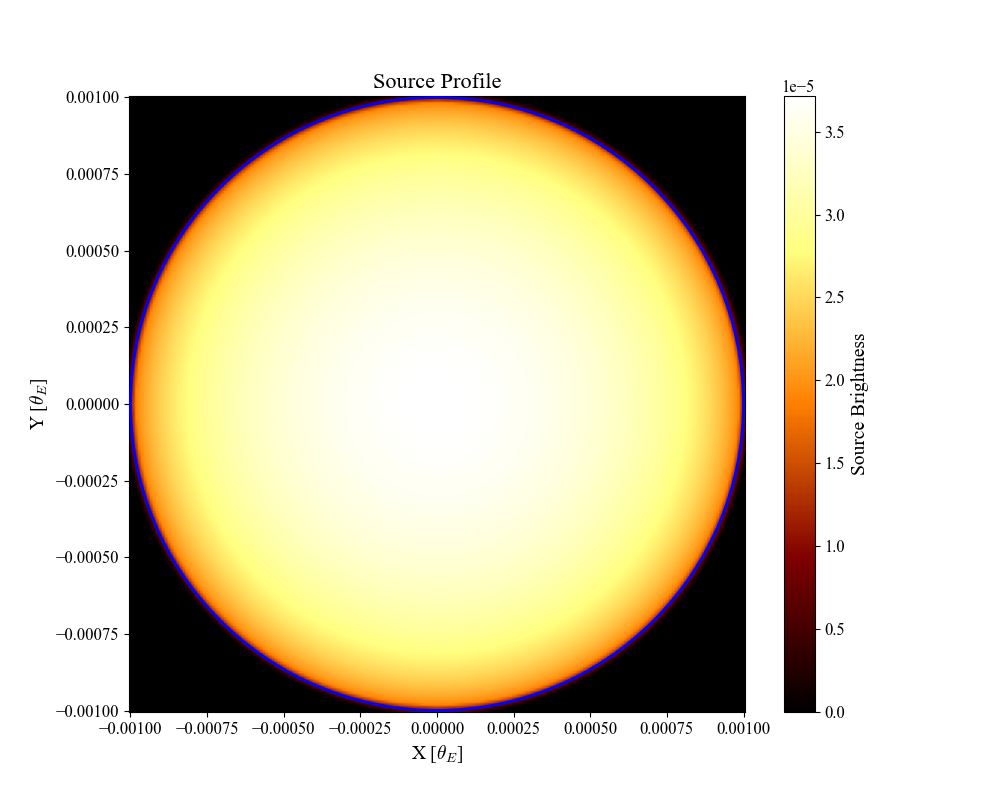

In [341]:
scale_factor = 4
new_ang_res = ang_res / scale_factor
radius = 1e-3
LD = 0.5

source_profile = IRSF.IRSFunctions.source_profile(ang_res=single_lens.param_dict['ang_res'], rad=radius, profile_type='LD', LD=LD, scale_factor=scale_factor, supersample=10)
print(source_profile.shape)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

img = ax.imshow(source_profile, cmap='afmhot', extent=[-radius - new_ang_res / 2, radius + new_ang_res / 2, -radius - new_ang_res / 2, radius + new_ang_res / 2])
plt.colorbar(img, ax=ax, label='Source Brightness')

source_patch = patches.Circle((0, 0), radius, color='blue', alpha=1, label='Source', zorder=10, fill=False, linewidth=2)
ax.add_patch(source_patch)

ax.set_xlabel('X [$\\theta_E$]')
ax.set_ylabel('Y [$\\theta_E$]')
ax.set_title('Source Profile')

ax.set_aspect('equal')

plt.show()

#### Helper functions to convert from Einstein coordinates to pixel indices and vice versa

In [343]:
def einstein_to_index(x_pix, y_pix, ang_width, pixels):
    ang_res = ang_width / (pixels - 1)

    if pixels % 2 == 0:  # even number of pixels
        x_ind = (x_pix + ang_width / 2) / ang_res
        y_ind = (ang_width / 2 + y_pix) / ang_res
    
    else:  # odd number of pixels
        x_ind = (x_pix + ang_width / 2) / ang_res
        y_ind = (ang_width / 2 + y_pix) / ang_res

    return x_ind, y_ind

def index_to_einstein(x_ind, y_ind, ang_width, pixels):
    ang_res = ang_width / (pixels - 1)

    if pixels % 2 == 0:
        # Even number of pixels
        x_pix = -ang_width / 2 + x_ind * ang_res
        y_pix = -ang_width / 2 + y_ind * ang_res
    else:
        # Odd number of pixels
        x_pix = -ang_width / 2 + x_ind * ang_res
        y_pix = -ang_width / 2 + y_ind * ang_res

    return x_pix, y_pix

#### Defining light curve function

In [407]:
import numpy as np
from scipy.ndimage import map_coordinates

def lightcurve_calculator_old(u, alpha, ang_width, map_array: np.ndarray, lens_CM: tuple | np.ndarray=(0, 0), offset: tuple | np.ndarray=(0, 0), n_samples: int=1e4):
    '''
    Calculates the light curve by interpolating magnification values along a line.

    Parameters
    ----------
    u : float
        Impact parameter from the lens center of mass
    alpha : float
        Angle of source trajectory from x axis in degrees
    ang_width : float
        Angular width of magnification map
    map_array : 2D NDArray
        Magnification map array
    lens_CM: 2-element tuple or NDArray
        Center of mass of lens system in scientific coordinates
    offset : 2-element tuple or NDArray, optional
        Current origin offset from star position in scientific coordinates
    n_samples : int, optional
        Number of interpolated samples along the trajectory

    Returns
    -------
    intersections : 2x2 NDArray
        First row is starting point, second row is ending point (in scientific coordinates)
    (xs, ys) : tuple of 1D NDArrays
        Scientific coordinates of the line
    times : 1D NDArray
        Array of time values along trajectory
    line_values : 1D NDArray
        Interpolated magnification values along the line
    '''
    u0 = u # Negate u to match the convention of the lensing model

    n_samples = int(n_samples)  # Ensure n_samples is an integer

    alpha = np.deg2rad(alpha)
    intersections = []

    # Center of trajectory in inertial frame
    x0_inert = u0 * np.sin(alpha)
    y0_inert = -u0 * np.cos(alpha)

    # Convert to COM frame (scientific coordinates)
    x0 = x0_inert - offset[0] + lens_CM[0]
    y0 = y0_inert - offset[1] + lens_CM[1]

    dx = np.cos(alpha)
    dy = np.sin(alpha)

    # Find entry and exit points of the trajectory through the square map
    for x_edge in [-ang_width/2, ang_width/2]:
        t = (x_edge - x0) / dx
        y = y0 + t*dy
        if -ang_width/2 <= y <= ang_width/2:
            intersections.append((x_edge, y))

    for y_edge in [-ang_width/2, ang_width/2]:
        t = (y_edge - y0) / dy
        x = x0 + t*dx
        if -ang_width/2 <= x <= ang_width/2:
            intersections.append((x, y_edge))

    if len(intersections) < 2:
        raise ValueError("Trajectory does not intersect the magnification map bounds.")

    intersections = np.array(intersections[:2])  # First two valid ones

    # Get start and end in scientific coordinates
    start = intersections[0]
    end = intersections[1]

    # Distance from center point to start/end in Einstein time units (assuming constant velocity)
    t_E_start = -np.hypot(*(start - [x0, y0]))
    t_E_end = np.hypot(*(end - [x0, y0]))
    times = np.linspace(t_E_start, t_E_end, n_samples)

    # Interpolated coordinates in scientific space
    xs = np.linspace(start[0], end[0], n_samples)
    ys = np.linspace(start[1], end[1], n_samples)

    # Convert to pixel indices (float) for interpolation
    pixels = map_array.shape[0]
    x_idx, y_idx = einstein_to_index(xs, ys, ang_width, pixels)

    # Interpolate using bilinear sampling (order=1)
    coords = np.vstack([y_idx, x_idx])  # row-major (y first)
    line_values = map_coordinates(map_array, coords, order=2, mode='nearest')

    return intersections, (xs, ys), (x0, y0), times, line_values

In [567]:
def lightcurve_calculator(u_0, alpha, t_0, t_E, map_array: np.ndarray, lens_CM: tuple | np.ndarray=(0, 0), offset: tuple | np.ndarray=(0, 0), n_samples: int=1e4):
    '''
    Calculates the light curve by interpolating magnification values along a line.

    Parameters
    ----------
    u_0 : float
        Impact parameter from the lens center of mass
    alpha : float
        Angle of source trajectory from x axis in degrees
    ang_width : float
        Angular width of magnification map
    map_array : 2D NDArray
        Magnification map array
    lens_CM: 2-element tuple or NDArray
        Center of mass of lens system in scientific coordinates
    offset : 2-element tuple or NDArray, optional
        Current origin offset from star position in scientific coordinates
    n_samples : int, optional
        Number of interpolated samples along the trajectory

    Returns
    -------
    intersections : 2x2 NDArray
        First row is starting point, second row is ending point (in scientific coordinates)
    (xs, ys) : tuple of 1D NDArrays
        Scientific coordinates of the line
    times : 1D NDArray
        Array of time values along trajectory
    line_values : 1D NDArray
        Interpolated magnification values along the line
    '''
    # Ensure n_samples is an integer
    n_samples = int(n_samples)

    # Convert alpha to radians
    alpha = np.deg2rad(alpha)
    
    # Defining intersections list
    intersections = []

    # Center of trajectory in inertial frame
    x0_inert = u_0 * np.sin(alpha)
    y0_inert = -u_0 * np.cos(alpha)

    # Convert to COM frame (scientific coordinates)
    x0 = x0_inert - offset[0] + lens_CM[0]
    y0 = y0_inert - offset[1] + lens_CM[1]

    dx = np.cos(alpha)
    dy = np.sin(alpha)

    # Find entry and exit points of the trajectory through the square map
    if dx == 0:
        # Vertical line case
        if -ang_width/2 <= x0 <= ang_width/2:
            intersections.append((x0, ang_width/2))
            intersections.append((x0, -ang_width/2))
    elif dy == 0:
        # Horizontal line case
        if -ang_width/2 <= y0 <= ang_width/2:
            intersections.append((ang_width/2, y0))
            intersections.append((-ang_width/2, y0))
    else:
        # General case
        for x_edge in [ang_width/2, -ang_width/2]:
            t = (x_edge - x0) / dx
            y = y0 + t*dy
            if -ang_width/2 <= y <= ang_width/2:
                intersections.append((x_edge, y))

        for y_edge in [ang_width/2, -ang_width/2]:
            t = (y_edge - y0) / dy
            x = x0 + t*dx
            if -ang_width/2 <= x <= ang_width/2:
                intersections.append((x, y_edge))

    if len(intersections) < 2:
        raise ValueError("Trajectory does not intersect the magnification map bounds.")

    intersections = np.array(intersections[:2])  # First two valid ones

    # Get start and end in scientific coordinates
    start = intersections[0]
    end = intersections[1]

    # Calculating start and end times in real time units
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        t_start_x = ((u_0 * np.sin(alpha) - start[0]) / np.cos(alpha))*t_E + t_0
        t_start_y = -((u_0 * np.cos(alpha) + start[1]) / np.sin(alpha))*t_E + t_0

        t_end_x = ((u_0 * np.sin(alpha) - end[0]) / np.cos(alpha))*t_E + t_0
        t_end_y = -((u_0 * np.cos(alpha) + end[1]) / np.sin(alpha))*t_E + t_0

    # Finding correct start and end times
    if alpha == 0 or alpha == 180:
        t_start = t_start_x
        t_end = t_end_x
    elif alpha == 90 or alpha == 270:
        t_start = t_start_y
        t_end = t_end_y
    else:
        t_start = np.mean([t_start_x, t_start_y])
        t_end = np.mean([t_end_x, t_end_y])

    # Defining time range for the trajectory
    times = np.linspace(t_start, t_end, n_samples)
    
    # Normalizing time to Einstein time units
    taus = (times - t_0) / t_E

    # Calculating x and y coordinates along trajectory
    xs = u_0*np.sin(alpha) - taus*np.cos(alpha)
    ys = -u_0*np.cos(alpha) - taus*np.sin(alpha)

    # Convert to pixel indices (float) for interpolation
    pixels = map_array.shape[0]
    x_idx, y_idx = einstein_to_index(xs, ys, ang_width, pixels)

    # Interpolate brightnesses
    coords = np.vstack([y_idx, x_idx])  # row-major (y first)
    line_values = map_coordinates(map_array, coords, order=1, mode='nearest')
    

    return intersections, (xs, ys), (x0, y0), times, line_values

#### Single lens

(8000, 8000)


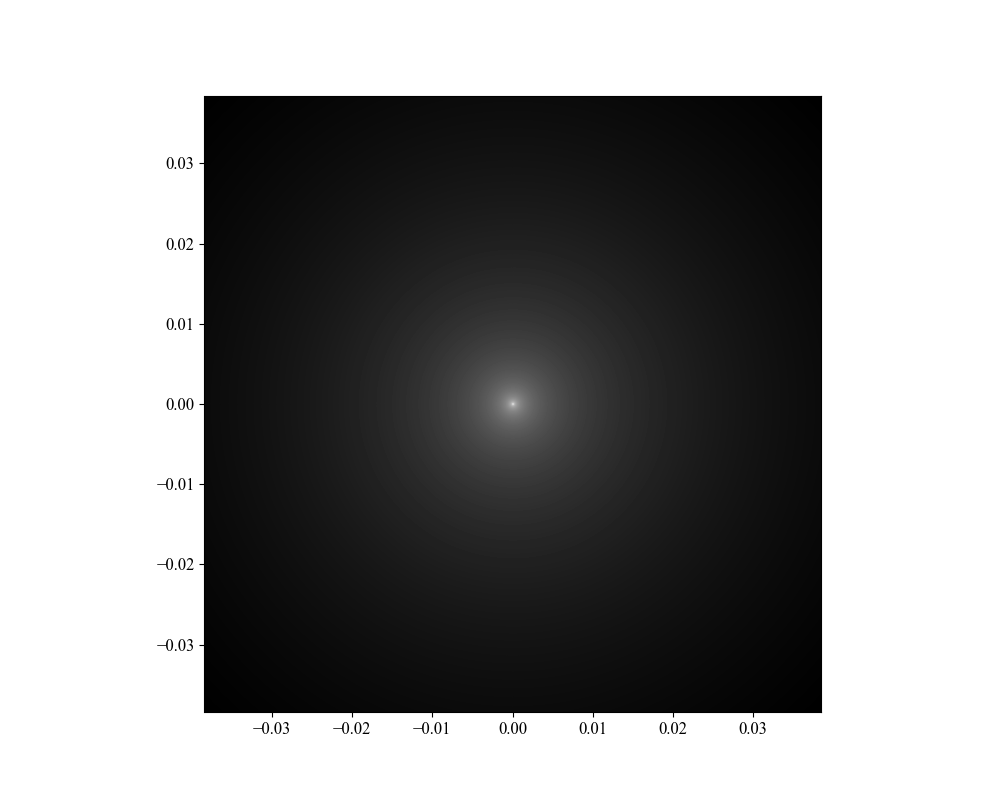

In [482]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

single_lens_counts = (single_lens.magnifications * sigma_ann) * old_A_pix  # Convert magnifications to counts
single_lens_magnifications = (single_lens_counts / A_pix) / sigma_ann

single_lens_uncertainty = single_lens_magnifications * 0.001

highres_image = zoom(single_lens_magnifications, scale_factor, order=1)  # bilinear interpolation
highres_uncertainty = zoom(single_lens_uncertainty, scale_factor, order=1)  # bilinear interpolation
print(highres_image.shape)

ax.imshow(np.log10(highres_image), cmap='grey', extent=[-ang_width/2 - new_ang_res/2, ang_width/2 + new_ang_res/2, -ang_width/2 - new_ang_res/2, ang_width/2 + new_ang_res/2])

plt.show()

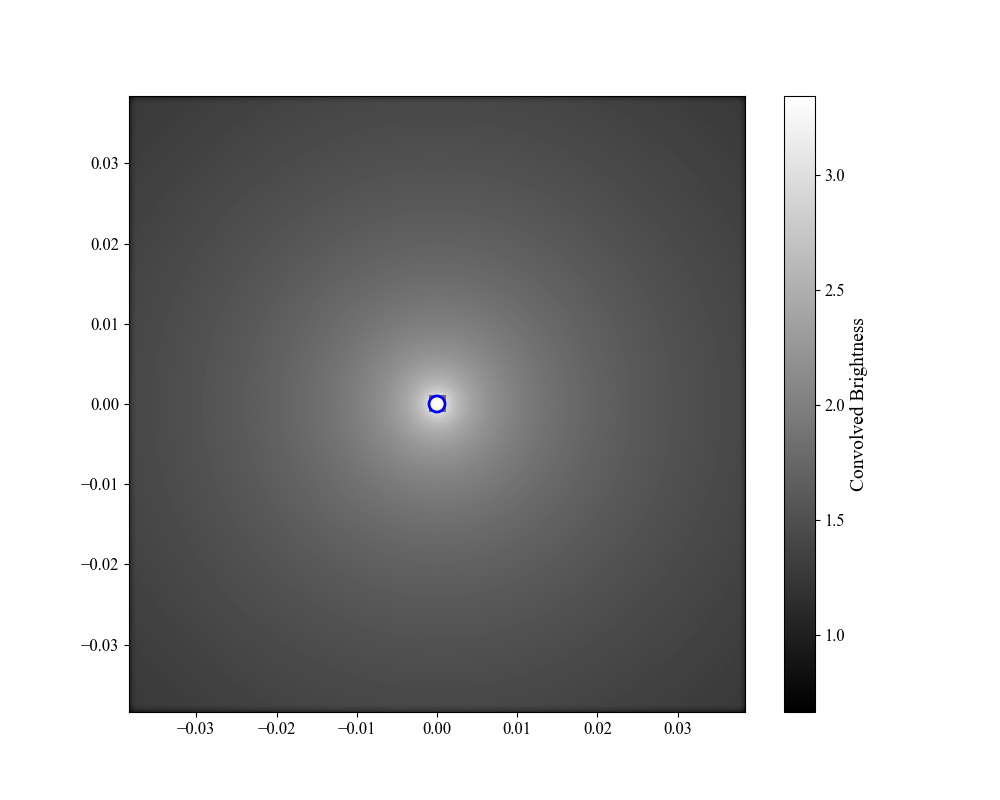

In [483]:
# convolved_brightnesses = binary_lens.convolve(source_profile)
highres_convolved_brightnesses = oaconvolve(highres_image, source_profile, mode='same')

# convolved_brightnesses = zoom(highres_convolved_brightnesses, 1/scale_factor, order=1)  # bilinear interpolation
convolved_brightnesses = highres_convolved_brightnesses

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()
img = ax.imshow(np.log10(convolved_brightnesses), cmap='grey', extent=[-ang_width/2 - new_ang_res/2, ang_width/2 + new_ang_res/2, -ang_width/2 - new_ang_res/2, ang_width/2 + new_ang_res/2])
plt.colorbar(img, ax=ax, label='Convolved Brightness')

# print(np.max(convolved_brightnesses), np.min(convolved_brightnesses))
# print(np.sum(convolved_brightnesses))

source_patch = patches.Circle((0, 0), radius, color='blue', alpha=1, label='Source', zorder=10, fill=False, linewidth=2)
ax.add_patch(source_patch)
ax.imshow(source_profile, cmap='afmhot', extent=[-radius - new_ang_res / 2, radius + new_ang_res / 2, -radius - new_ang_res / 2, radius + new_ang_res / 2], alpha=0.5)

ax.set_xlim(-ang_width/2 - new_ang_res / 2, ang_width/2 + new_ang_res / 2)
ax.set_ylim(-ang_width/2 - new_ang_res / 2, ang_width/2 + new_ang_res / 2)

plt.show()

In [548]:
u_0 = 0.005
alpha = 0
t_E = 1.0
t_0 = 0.0

intersections_old, (xs_old, ys_old), (x0_old, y0_old), times_old, brightnesses_old = lightcurve_calculator_old(u_0, alpha, ang_width, convolved_brightnesses)
intersections, (xs, ys), (x0, y0), times, brightnesses = lightcurve_calculator(u_0, alpha, t_0, t_E, convolved_brightnesses)

intersections, (xs, ys), (x0, y0), times, uncertainties = lightcurve_calculator(u_0, alpha, t_0, t_E, single_lens_uncertainty)

/var/folders/39/mb5cwg0x4h18n1y377g5rs9c0000gn/T/ipykernel_15577/3160903171.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  t = (y_edge - y0) / dy


In [549]:
mm_param_dict = {'t_0': t_0, 't_E': t_E, 'u_0': u_0, 'rho': radius}
# mm_param_dict = {'t_0': -0.00001, 't_E': 1.00437, 'u_0': 0.00797, 'rho': 1.02207e-03}

single_model = mm.Model(mm_param_dict)

single_model.default_magnification_method = 'finite_source_LD_Yoo04'

mm_brightnesses = single_model.get_magnification(times, gamma=LD)
mm_trajectory = single_model.get_trajectory(times)

mm_brightnesses_old = single_model.get_magnification(times_old, gamma=LD)
mm_trajectory_old = single_model.get_trajectory(times_old)

0.0


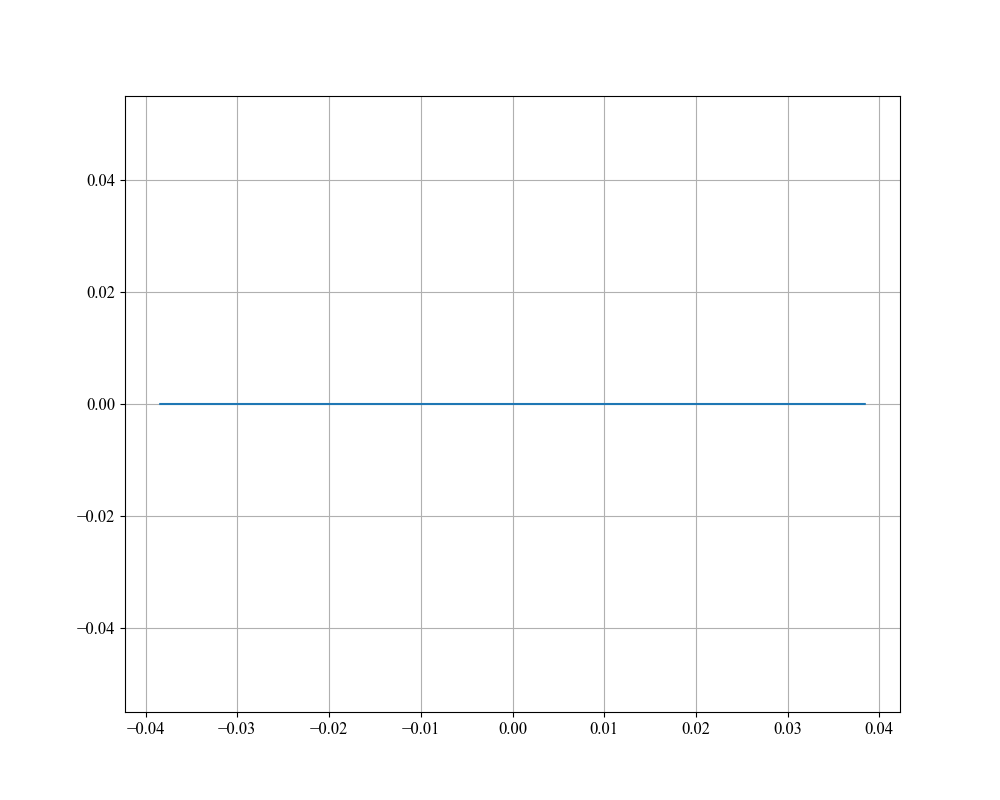

In [550]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

mm_xs = mm_trajectory.x
mm_ys = mm_trajectory.y

diff = (xs_old - mm_xs) / mm_xs

# ax.plot(numerical_times, numerical_xs, color='orange', label='Numerical X', linewidth=2)
# ax.plot(numerical_times, mm_xs, color='red', label='MulensModel X', linewidth=2)
ax.plot(times, diff)

print(np.max(np.abs(diff)))

ax.grid()

plt.show()

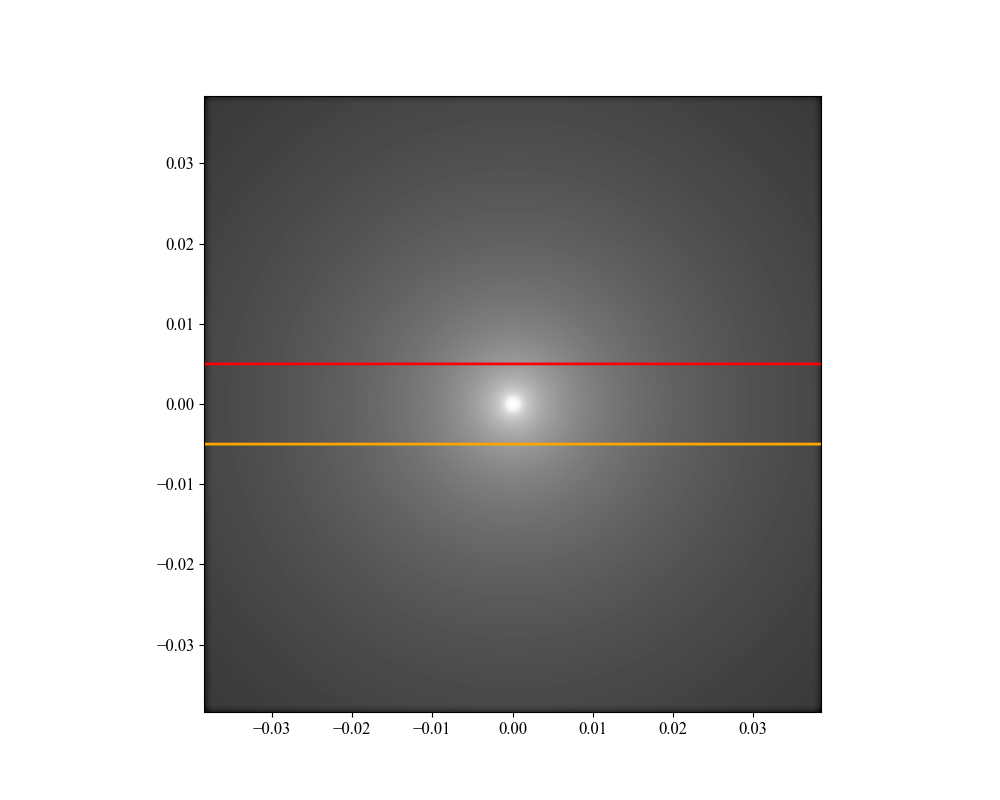

In [564]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

ax.imshow(np.log10(convolved_brightnesses), cmap='grey', extent=[-ang_width/2 - new_ang_res/2, ang_width/2 + new_ang_res/2, -ang_width/2 - new_ang_res/2, ang_width/2 + new_ang_res/2])
ax.plot(xs, ys, color='orange', label='Numerical Trajectory', linewidth=2)
# ax.plot(xs_old, ys_old, color='blue', label='Old Numerical Trajectory', linewidth=2)
ax.plot(mm_trajectory.x, mm_trajectory.y, color='red', label='MulensModel Trajectory', linewidth=2)

plt.show()

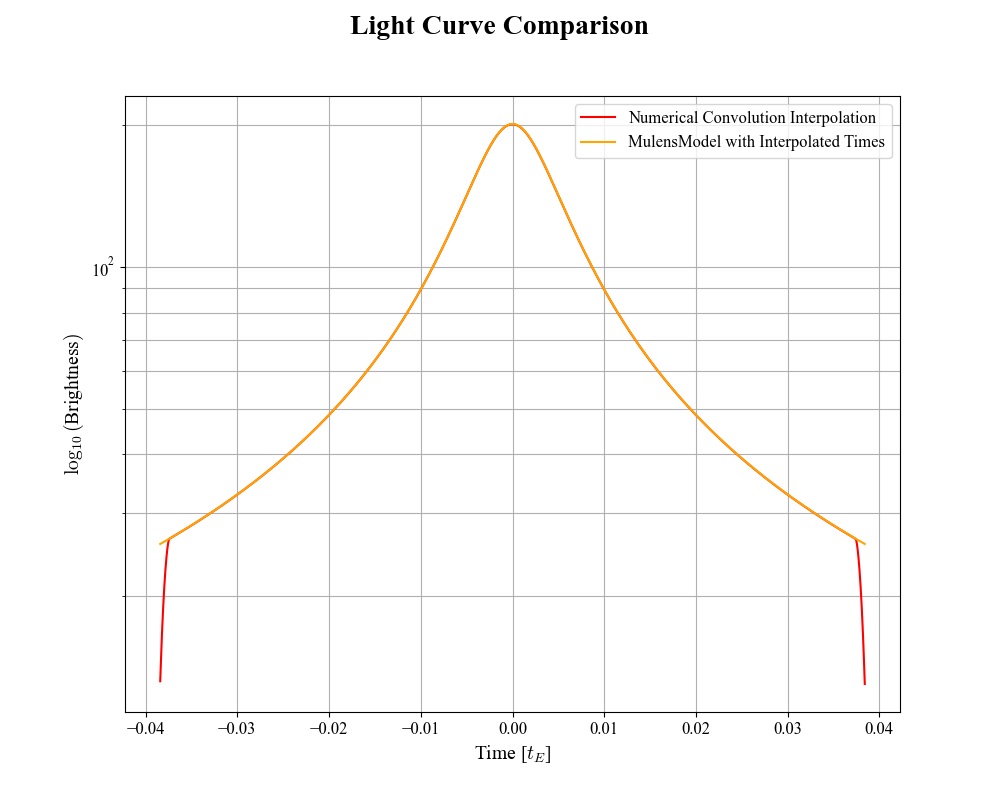

In [563]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

fig.suptitle('Light Curve Comparison')

# ax.semilogy(times_old, brightnesses_old, label='Old Numerical Convolution Interpolation', color='blue')
ax.semilogy(times, brightnesses, label='Numerical Convolution Interpolation', color='red')

# ax.semilogy(times_old, mm_brightnesses_old, label='Old MulensModel with Interpolated Times', color='green')
ax.semilogy(times, mm_brightnesses, label='MulensModel with Interpolated Times', color='orange')

ax.set_xlabel('Time [$t_E$]')
ax.set_ylabel('$\log_{10}($Brightness$)$')

ax.grid(True, 'both')
ax.legend()

plt.show()

0.0012750598726648027


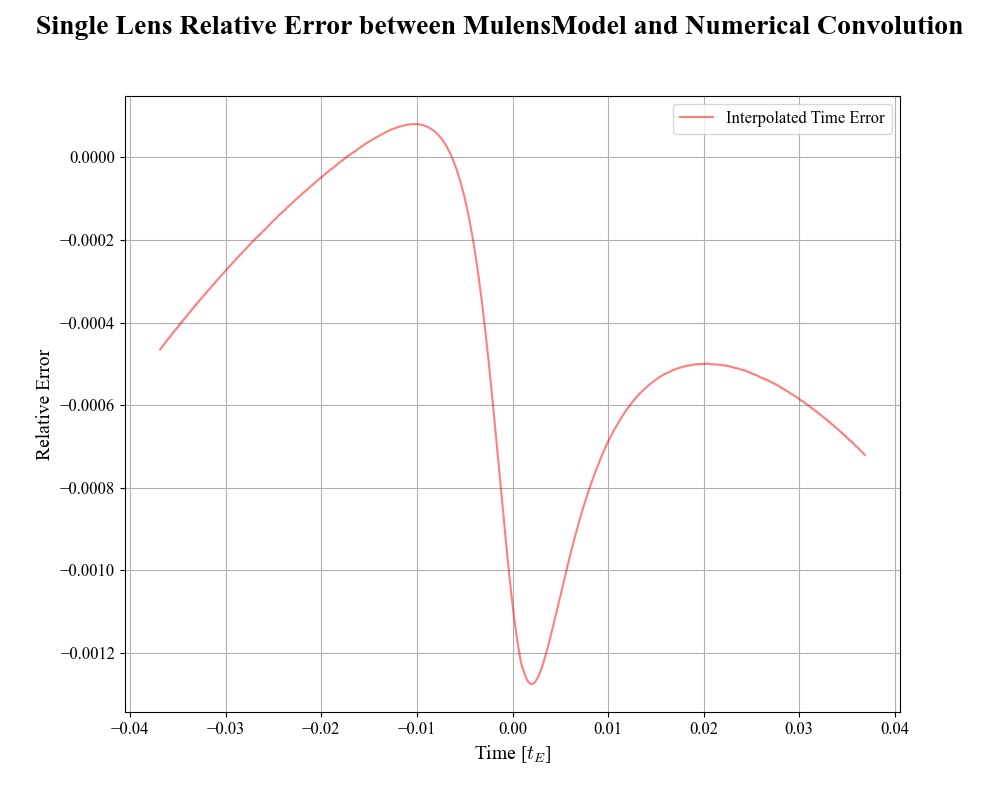

In [553]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

fig.suptitle('Single Lens Relative Error between MulensModel and Numerical Convolution')

fractional_difference_old = (brightnesses_old - mm_brightnesses_old) / mm_brightnesses_old
fractional_difference = (brightnesses - mm_brightnesses) / mm_brightnesses

# ax.plot(times_old[200:9800], fractional_difference_old[200:9800], label='Old Interpolated Time Error', color='blue', alpha=0.5)
ax.plot(times[200:9800], fractional_difference[200:9800], label='Interpolated Time Error', color='red', alpha=0.5)

print(np.nanmax(np.abs(fractional_difference[200:9800])))

ax.grid()
ax.legend()
# ax.set_xlim(-0.03, 0.03)
# ax.set_ylim(-0.005, 0.005)

ax.set_xlabel('Time [$t_E$]')
ax.set_ylabel('Relative Error')

plt.show()

#### Light curve fitting

In [554]:
import scipy.optimize as opt

def chi2_for_model(theta, event: mm.Event, parameters_to_fit: list):
    """
    for given event set attributes from parameters_to_fit
    (list of str) to values from the theta list
    """
    for (key, parameter) in enumerate(parameters_to_fit):
        setattr(event.model.parameters, parameter, theta[key])
    return event.get_chi2()

data = [
    times[200:9800],
    brightnesses[200:9800],
    uncertainties[200:9800]
]

print(np.shape(data))

(3, 9600)


Initial Chi2: 1163.3065707095482


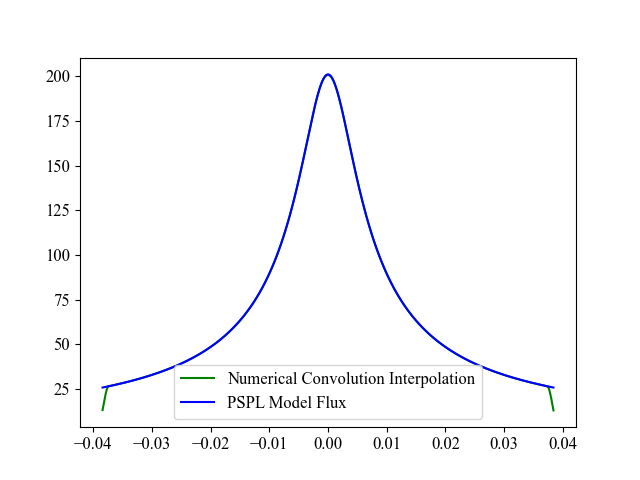

In [ ]:
parameters_to_fit = ['t_0', 't_E', 'u_0', 'rho']
initial_guess = [t_0-0.0001, t_E+0.0001, u_0+0.0001, radius+0.0001]
actual_params = [t_0, t_E, u_0, radius]

pspl_model = mm.Model({'t_0': t_0, 't_E': t_E, 'u_0': u_0, 'rho': radius})
pspl_model.default_magnification_method = 'finite_source_LD_Yoo04'
pspl_model.set_limb_coeff_gamma("H", 0.5)

my_data = mm.MulensData(
    data_list=data,
    plot_properties={'color': 'thistle', 'label': "Sai's data", 'marker': '.', 'markersize': 0.5, 'alpha': 0.5},
    phot_fmt='flux',
    chi2_fmt='flux',
    bandpass='H'
)

my_event = mm.Event(datasets=my_data, model=pspl_model)
initial_chi2 = chi2_for_model(
    theta=initial_guess,
    event=my_event,
    parameters_to_fit=parameters_to_fit
)

print(f'Initial Chi2: {initial_chi2}')

# my_event.plot_data()
pspl_model_mag = my_event.model.get_lc(times=times, source_flux=1, blend_flux=0)
pspl_model_flux = mm.Utils.get_flux_from_mag(pspl_model_mag)

plt.plot(times, brightnesses, label='Numerical Convolution Interpolation', color='green')
plt.plot(times, pspl_model_flux, label='PSPL Model Flux', color='blue')

plt.legend()
plt.show()

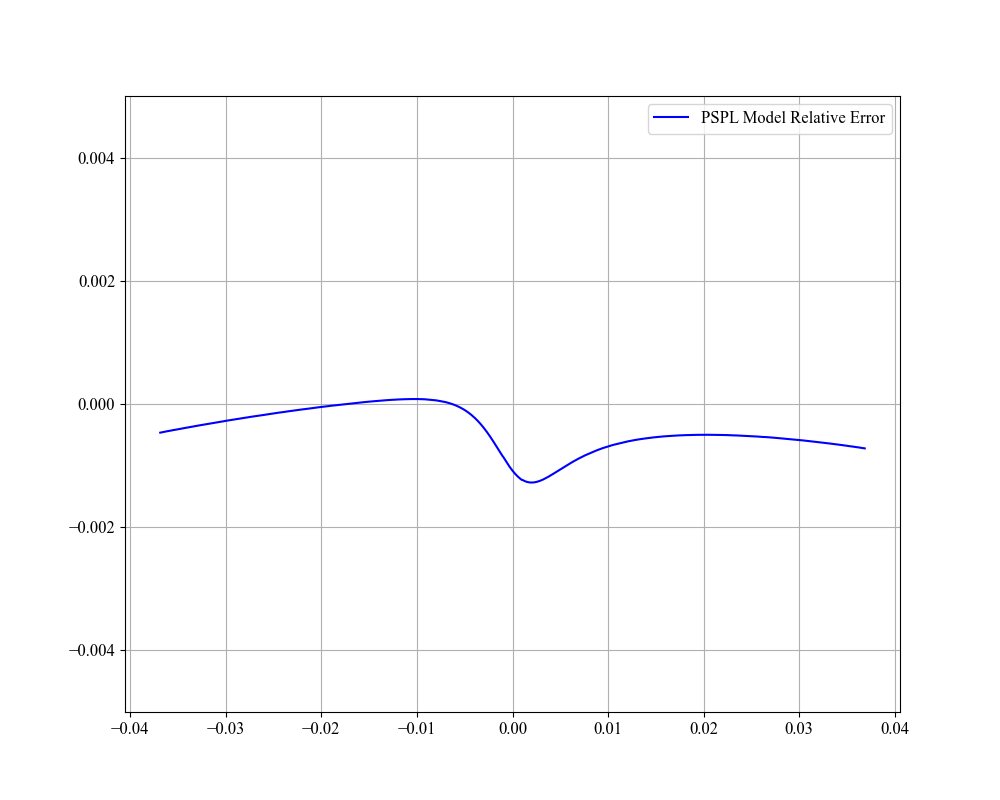

In [556]:
pspl_model_mags = pspl_model.get_magnification(times, gamma=LD)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

model_err = (brightnesses - pspl_model_mags) / pspl_model_mags

# ax.semilogy(times, pspl_model_mags, label='PSPL Model Magnification', color='blue')
# ax.semilogy(times, brightnesses, label='Numerical Convolution Interpolation', color='green')

ax.plot(times[200:9800], model_err[200:9800], label='PSPL Model Relative Error', color='blue')
ax.set_ylim(-0.005, 0.005)

ax.grid()
ax.legend()

plt.show()

In [566]:
result = opt.minimize(chi2_for_model, initial_guess, args=(my_event, parameters_to_fit), method='Nelder-Mead', tol=1e-4, options={'maxfev': 2000})

print("Fitting was successful? {:}".format(result.success))
if not result.success:
    print(result.message)
print("Function evaluations: {:}".format(result.nfev))
if isinstance(result.fun, np.ndarray):
    if result.fun.ndim == 0:
        result_fun = float(result.fun)
    else:
        result_fun = result.fun[0]
else:
    result_fun = result.fun

print("The smallest function value: {}".format(result_fun))
# print("for parameters: {:.5e} {:.5f}".format(*result.x.tolist()))

print('\nParameter = fitted value (expected inputted value)')
print('--------------------------------------------------')

fitted_parameters = []
for result_param, param_name, actual_param in zip(result.x.tolist(), parameters_to_fit, actual_params):
    print(f"{param_name} = {result_param:.5f} (expected {actual_param:.3f})")
    fitted_parameters.append(result_param)

print(f'\nInitial chi2: {initial_chi2:.3f}')
# print(f'Final chi2: {(result_fun * (9600 - 4)):.3f}')
print(f'Final chi2: {(result_fun):.3f}')

Fitting was successful? True
Function evaluations: 1257
The smallest function value: 7.837666246748655

Parameter = fitted value (expected inputted value)
--------------------------------------------------
t_0 = -0.00000 (expected 0.000)
t_E = 0.81846 (expected 1.000)
u_0 = 0.00609 (expected 0.005)
rho = 0.00034 (expected 0.001)

Initial chi2: 1163.307
Final chi2: 7.838


In [558]:
dataset = my_event.datasets[0]
my_event.fit_fluxes()
([FS], FB) = my_event.get_flux_for_dataset(dataset)

print(FS, FB)

1.2221009927108402 -0.02679835371294439


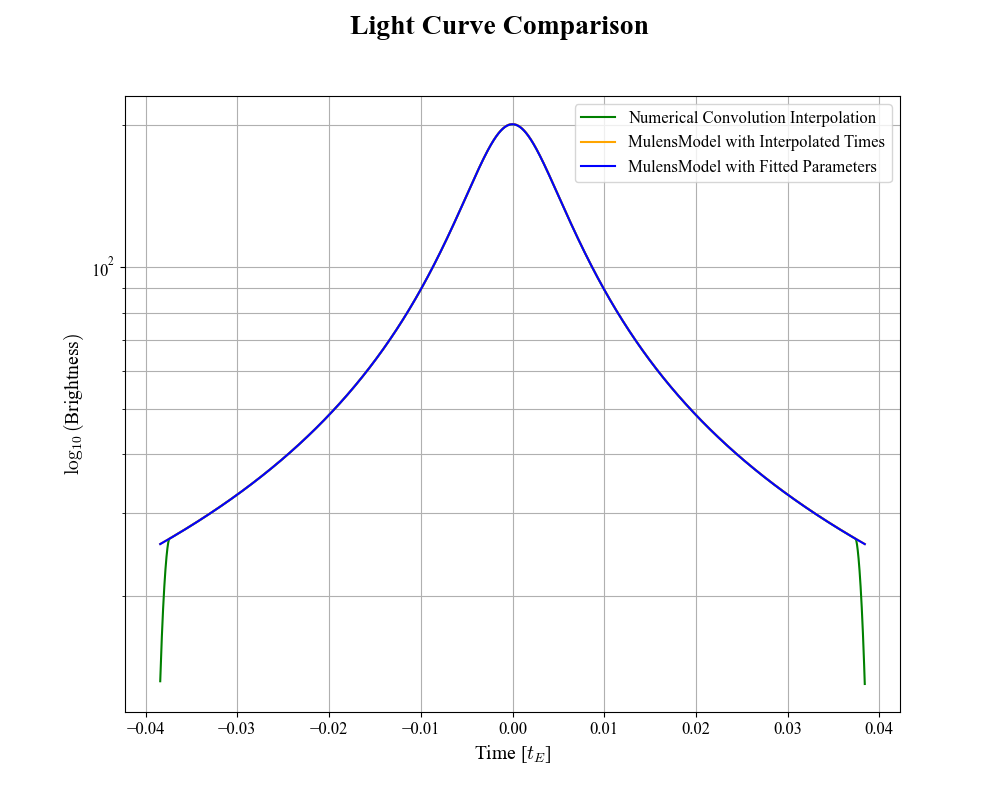

In [559]:
sourceflux = FS
blendflux = FB

new_model_mag = my_event.model.get_lc(times=times, source_flux=sourceflux, blend_flux=blendflux)
new_model_flux = mm.Utils.get_flux_from_mag(new_model_mag)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

fig.suptitle('Light Curve Comparison')

ax.semilogy(times, brightnesses, label='Numerical Convolution Interpolation', color='green')
ax.semilogy(times, mm_brightnesses, label='MulensModel with Interpolated Times', color='orange')
# ax.semilogy(times, new_mm_brightnesses, label='MulensModel with Fitted Parameters', color='blue')
ax.semilogy(times, new_model_flux, label='MulensModel with Fitted Parameters', color='blue')

ax.set_xlabel('Time [$t_E$]')
ax.set_ylabel('$\log_{10}($Brightness$)$')

ax.grid(True, 'both')
ax.legend()

plt.show()

0.0012750598726648027
7.233521735543688e-05


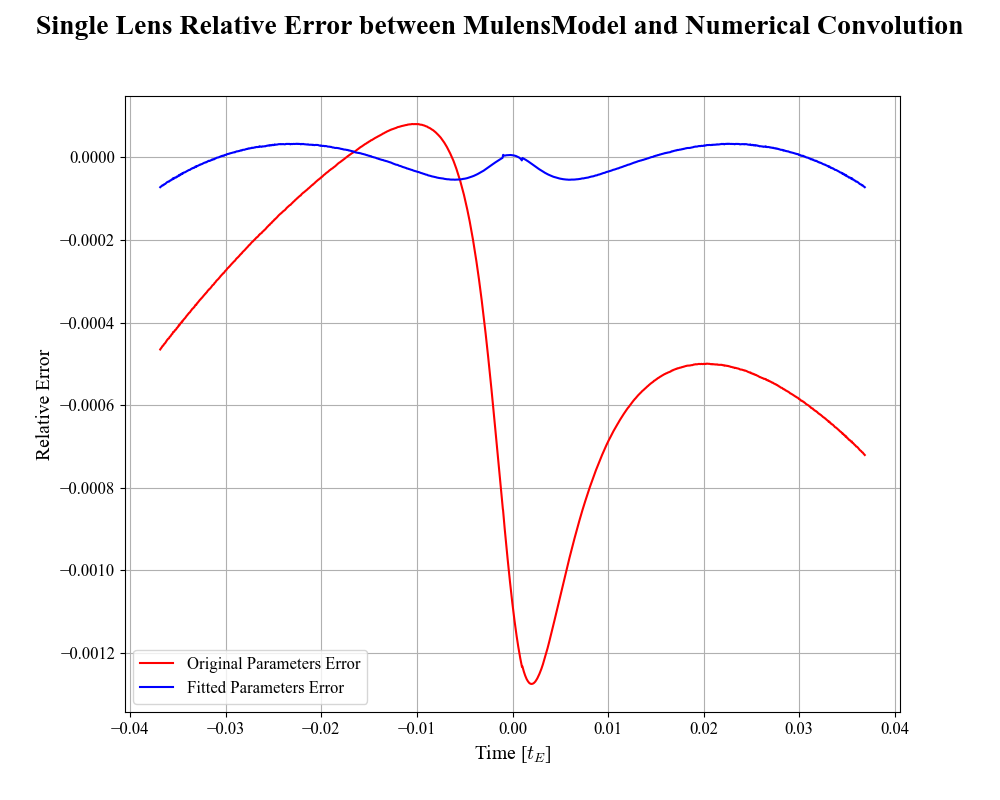

In [562]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

fig.suptitle('Single Lens Relative Error between MulensModel and Numerical Convolution')

# ax.set_title(f'{actual_params}')

fractional_difference = (brightnesses - mm_brightnesses) / mm_brightnesses
new_fractional_difference = (brightnesses - new_model_flux) / new_model_flux

ax.plot(times[200:9800], fractional_difference[200:9800], label='Original Parameters Error', color='red')
ax.plot(times[200:9800], new_fractional_difference[200:9800], label='Fitted Parameters Error', color='blue')

print(np.nanmax(np.abs(fractional_difference[200:9800])))
print(np.nanmax(np.abs(new_fractional_difference[200:9800])))

ax.grid()
ax.legend()
# ax.set_xlim(-0.03, 0.03)
# ax.set_ylim(-0.005, 0.005)

ax.set_xlabel('Time [$t_E$]')
ax.set_ylabel('Relative Error')

plt.show()

#### Binary lens testing

(8000, 8000)


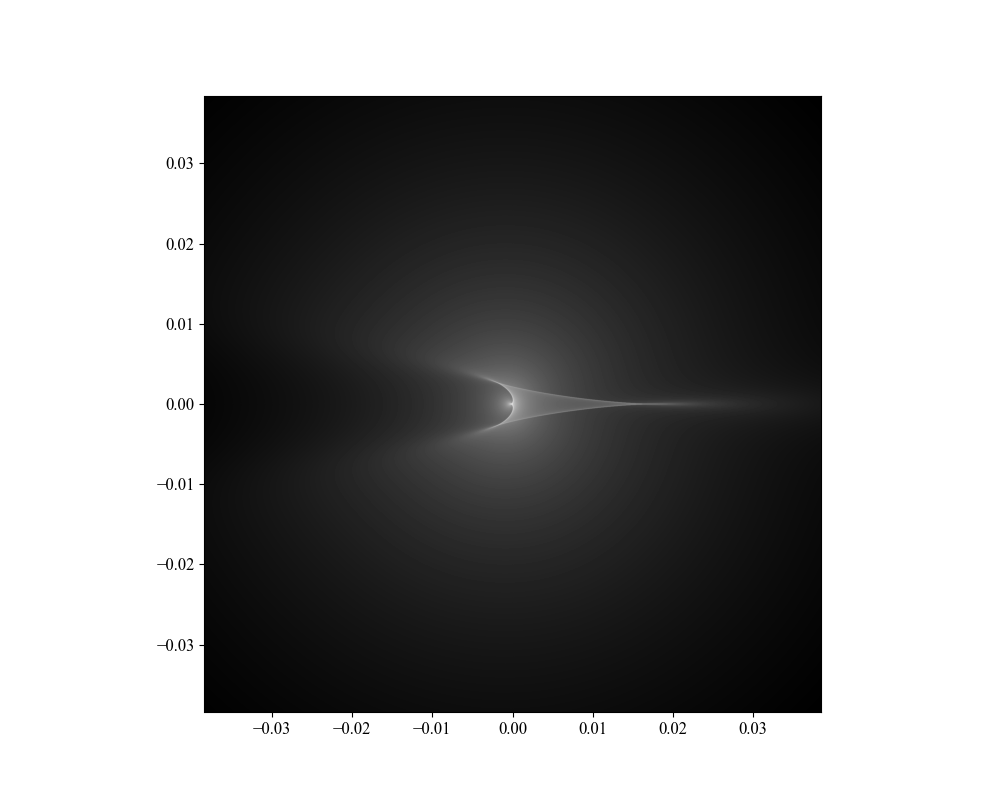

In [568]:
# binary_lens.plot()
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

binary_lens_counts = (binary_lens.magnifications * sigma_ann) * old_A_pix  # Convert magnifications to counts
binary_lens_magnifications = (binary_lens_counts / A_pix) / sigma_ann

binary_lens_uncertainty = binary_lens_magnifications * 0.001

highres_image = zoom(binary_lens_magnifications, scale_factor, order=1)  # bilinear interpolation
highres_uncertainty = zoom(binary_lens_uncertainty, scale_factor, order=1)  # bilinear interpolation
print(highres_image.shape)

ax.imshow(np.log10(highres_image), cmap='grey', extent=[-ang_width/2 - new_ang_res/2, ang_width/2 + new_ang_res/2, -ang_width/2 - new_ang_res/2, ang_width/2 + new_ang_res/2])

plt.show()

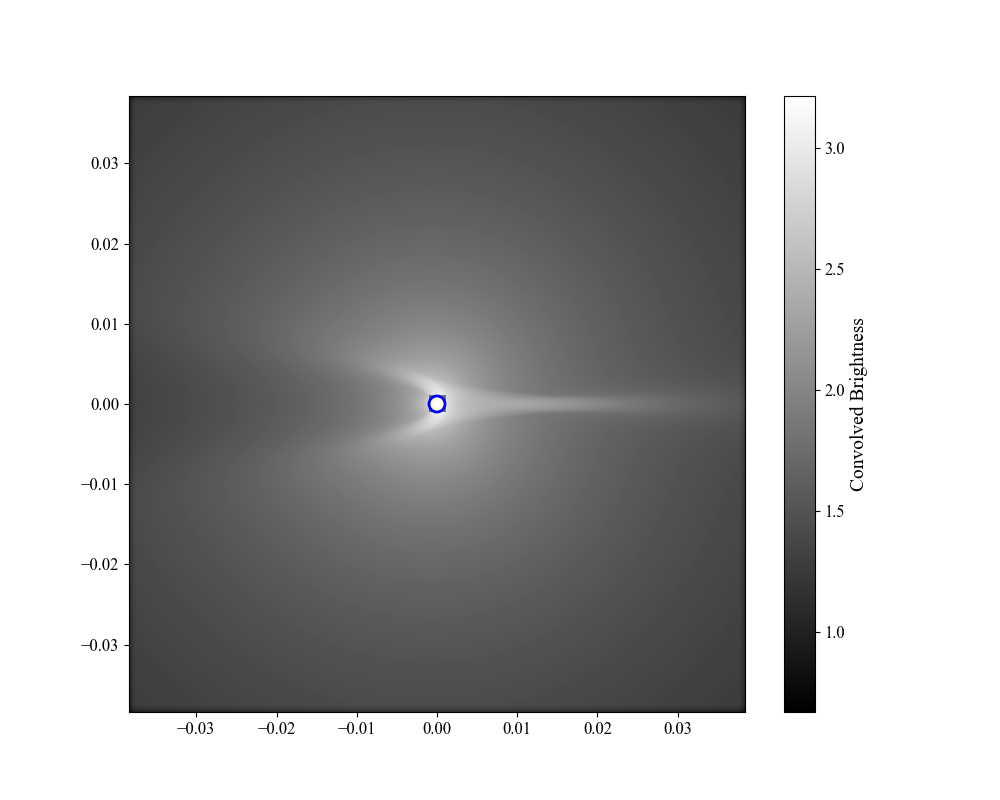

In [569]:
# convolved_brightnesses = binary_lens.convolve(source_profile)
highres_convolved_brightnesses = oaconvolve(highres_image, source_profile, mode='same')

# convolved_brightnesses = zoom(highres_convolved_brightnesses, 1/scale_factor, order=1)  # bilinear interpolation
convolved_brightnesses = highres_convolved_brightnesses

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()
img = ax.imshow(np.log10(convolved_brightnesses), cmap='grey', extent=[-ang_width/2 - new_ang_res/2, ang_width/2 + new_ang_res/2, -ang_width/2 - new_ang_res/2, ang_width/2 + new_ang_res/2])
plt.colorbar(img, ax=ax, label='Convolved Brightness')

# print(np.max(convolved_brightnesses), np.min(convolved_brightnesses))
# print(np.sum(convolved_brightnesses))

source_patch = patches.Circle((0, 0), radius, color='blue', alpha=1, label='Source', zorder=10, fill=False, linewidth=2)
ax.add_patch(source_patch)
ax.imshow(source_profile, cmap='afmhot', extent=[-radius - new_ang_res / 2, radius + new_ang_res / 2, -radius - new_ang_res / 2, radius + new_ang_res / 2], alpha=0.5)

ax.set_xlim(-ang_width/2 - new_ang_res / 2, ang_width/2 + new_ang_res / 2)
ax.set_ylim(-ang_width/2 - new_ang_res / 2, ang_width/2 + new_ang_res / 2)

plt.show()

In [570]:
u_0 = 0.005
alpha = 30
t_E = 1.0
t_0 = 0.0

intersections_old, (xs_old, ys_old), (x0_old, y0_old), times_old, brightnesses_old = lightcurve_calculator_old(u_0, alpha, ang_width, convolved_brightnesses, lens_CM=lens_CM, offset=delta1)
intersections, (xs, ys), (x0, y0), times, brightnesses = lightcurve_calculator(u_0, alpha, t_0, t_E, convolved_brightnesses, lens_CM=lens_CM, offset=delta1)

intersections, (xs, ys), (x0, y0), times, uncertainties = lightcurve_calculator(u_0, alpha, t_0, t_E, binary_lens_uncertainty, lens_CM=lens_CM, offset=delta1)

In [571]:
mm_param_dict = {'t_0': t_0, 't_E': t_E, 'u_0': u_0, 'rho': radius, 'q': 1e-3, 'alpha': alpha, 's': 0.8}

binary_model = mm.Model(mm_param_dict)

binary_model.default_magnification_method = 'VBBL'

mm_brightnesses = binary_model.get_magnification(times, gamma=LD)
mm_trajectory = binary_model.get_trajectory(times)

mm_brightnesses_old = binary_model.get_magnification(times_old, gamma=LD)
mm_trajectory_old = binary_model.get_trajectory(times_old)

0.0
104.54727261114164


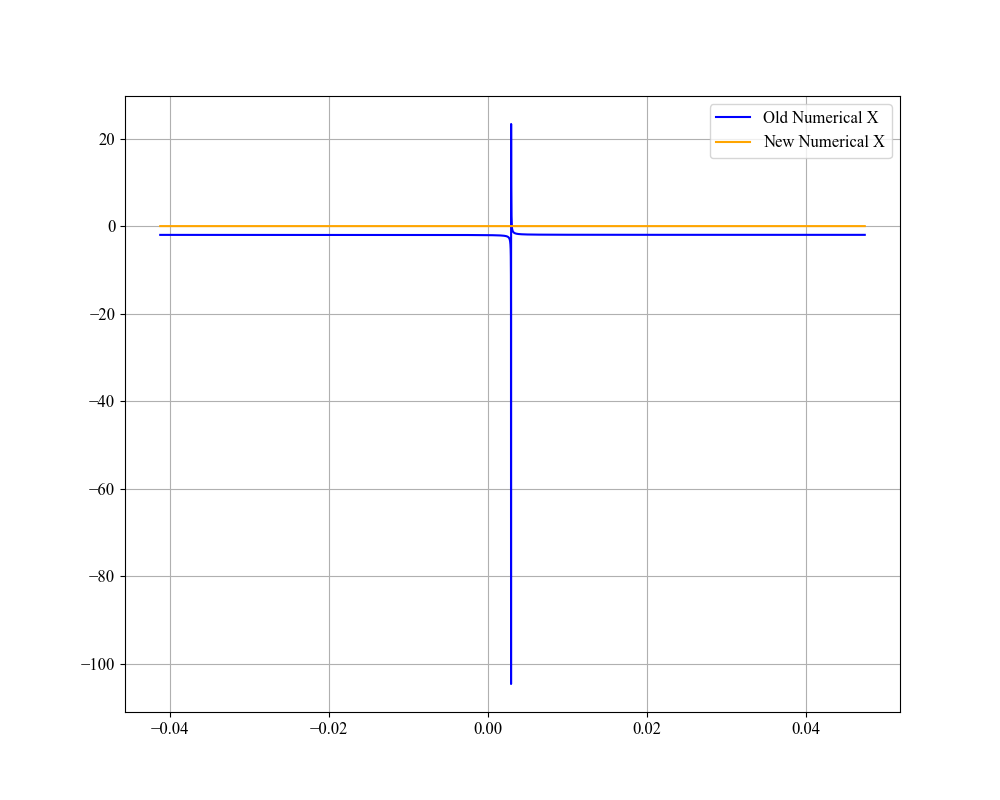

In [572]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

mm_xs = mm_trajectory.x
mm_ys = mm_trajectory.y

diff_old = (xs_old - mm_xs) / mm_xs
diff = (xs - mm_xs) / mm_xs

# ax.plot(numerical_times, numerical_xs, color='orange', label='Numerical X', linewidth=2)
# ax.plot(numerical_times, mm_xs, color='red', label='MulensModel X', linewidth=2)
ax.plot(times, diff_old, label='Old Numerical X', color='blue')
ax.plot(times, diff, label='New Numerical X', color='orange')

print(np.max(np.abs(diff)))
print(np.max(np.abs(diff_old)))

ax.grid()
ax.legend()

plt.show()

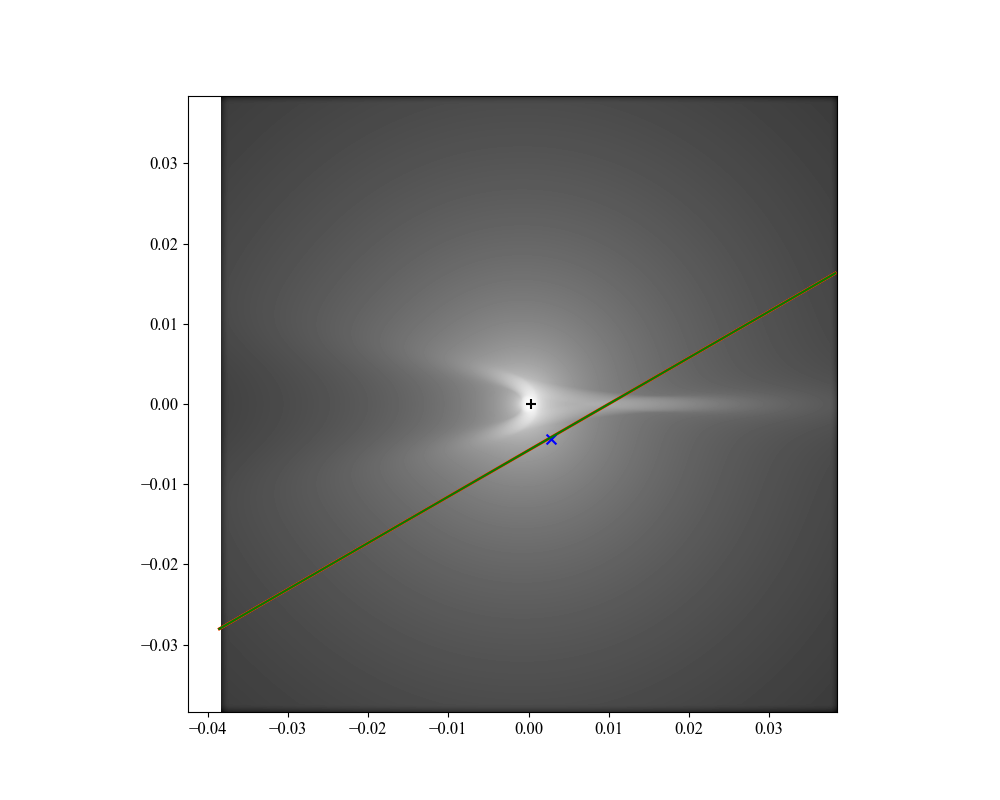

In [573]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

ax.imshow(np.log10(convolved_brightnesses), cmap='grey', extent=[-ang_width/2 - new_ang_res/2, ang_width/2 + new_ang_res/2, -ang_width/2 - new_ang_res/2, ang_width/2 + new_ang_res/2])
ax.plot(xs, ys, color='orange', label='Numerical Trajectory', linewidth=2)
ax.plot(mm_trajectory.x, mm_trajectory.y, color='red', label='MulensModel Trajectory', linewidth=2)

ax.scatter(*(lens_CM - delta1), color='black', s=50, label='Lens Center of Mass', zorder=10, marker='+')
ax.scatter(x0, y0, color='blue', s=50, label='Trajectory Origin', zorder=10, marker='x')

ax.plot(xs, ys, color='green', label='Impact Parameter', zorder=10)

plt.show()

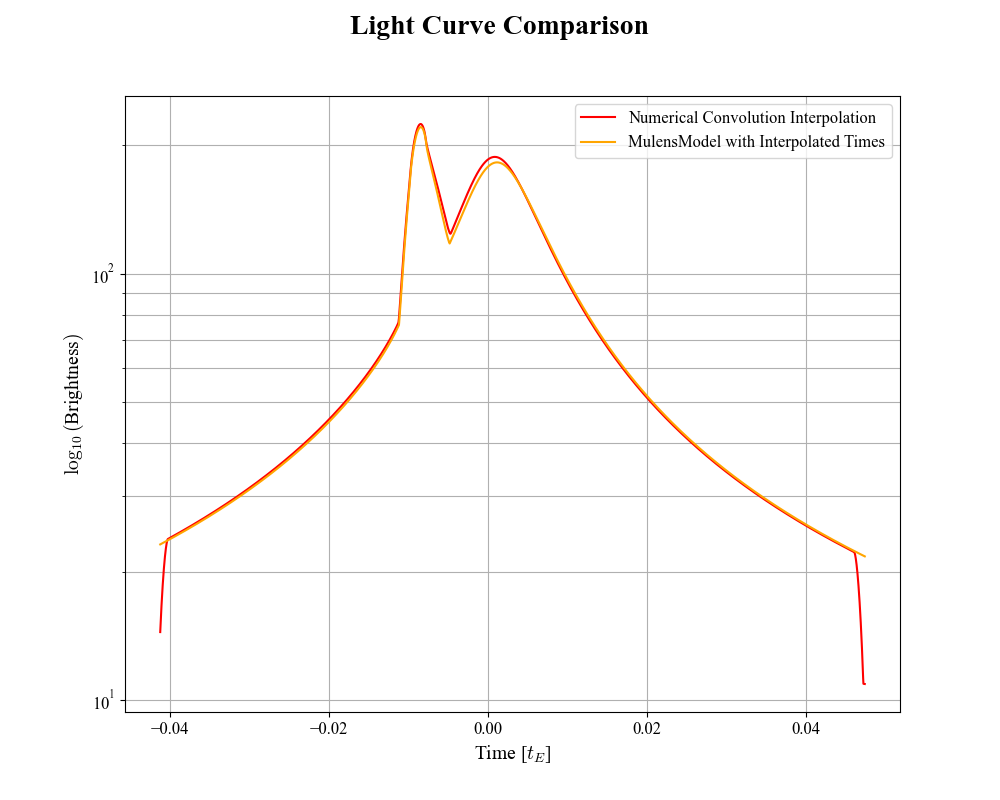

In [574]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

fig.suptitle('Light Curve Comparison')

# ax.semilogy(numerical_times, numerical_brightnesses, label='Numerical Convolution', color='blue')
# ax.semilogy(numerical_times, mm_brightnesses, label='MulensModel with Pixel Times', color='green')
ax.semilogy(times, brightnesses, label='Numerical Convolution Interpolation', color='red')
ax.semilogy(times, mm_brightnesses, label='MulensModel with Interpolated Times', color='orange')

ax.set_xlabel('Time [$t_E$]')
ax.set_ylabel('$\log_{10}($Brightness$)$')

ax.grid(True, 'both')
ax.legend()

plt.show()

0.060714199320000745


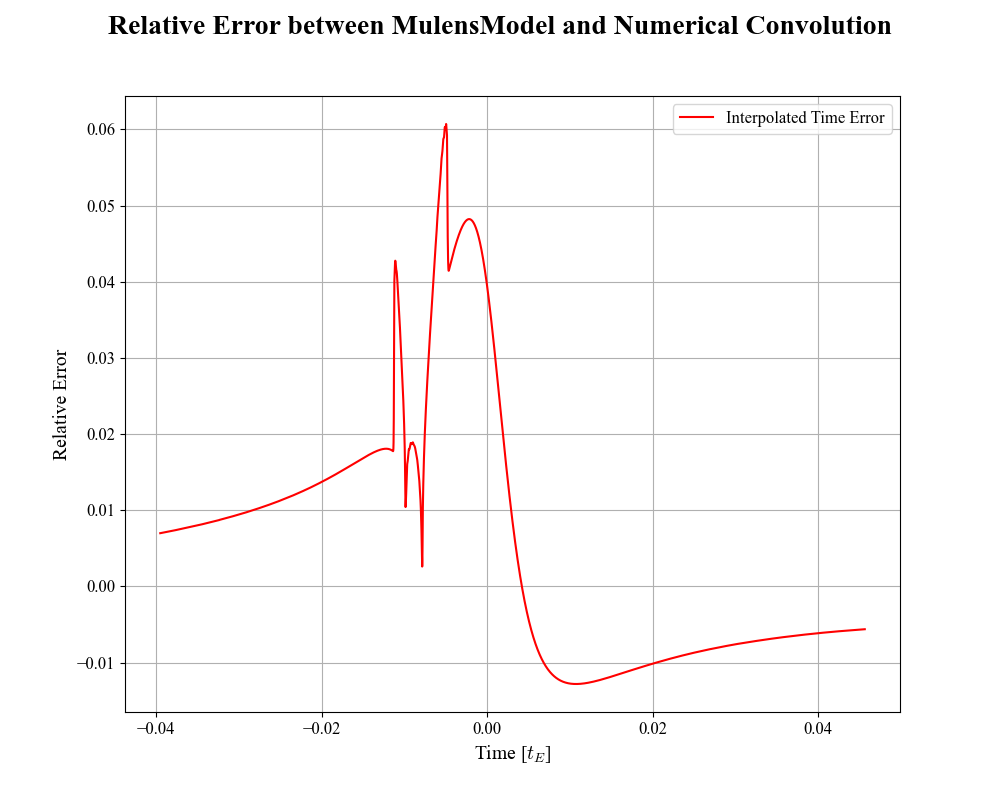

In [466]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

fig.suptitle('Relative Error between MulensModel and Numerical Convolution')

fractional_difference = (brightnesses - mm_brightnesses) / mm_brightnesses
# fractional_difference2 = (numerical2_brightnesses - mm2_brightnesses) / mm2_brightnesses

ax.plot(times[200:9800], fractional_difference[200:9800], label='Interpolated Time Error', color='red')

print(np.nanmax(np.abs(fractional_difference[200:9800])))

ax.grid()
ax.legend()
# ax.set_xlim(-0.004, 0.004)
# ax.set_ylim(-0.06, 0.06)

ax.set_xlabel('Time [$t_E$]')
ax.set_ylabel('Relative Error')

plt.show()